<u><b>Car Price Prediction Dashboard

<u><b>Problem: Develop an interface to predict used car prices using features like year, fuel type, and mileage. 
Task: 
1.	Load and clean car dataset.
2.	Perform regression modeling.
3.	Visualize feature importance.
4.	Create user input interface.
5.	Display predicted price with charts.

<b><u>STEP 1: Install and Import Libraries

In [30]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score


<u><b>STEP 2: Load and Clean Dataset

In [32]:
# Load dataset
df = pd.read_csv("car data.csv")

# Show first rows
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [33]:
# Check missing values
print(df.isnull().sum())

# Drop missing values (simple method)
df = df.dropna()

# View dataset info
df.info()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

<u><b>STEP 3: Convert Categorical Data (Encoding)

In [36]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Fuel_Type'] = le.fit_transform(df['Fuel_Type'])
df['Seller_Type'] = le.fit_transform(df['Seller_Type'])   # ✅ FIXED
df['Transmission'] = le.fit_transform(df['Transmission'])

df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,2,0,1,0
1,sx4,2013,4.75,9.54,43000,1,0,1,0
2,ciaz,2017,7.25,9.85,6900,2,0,1,0
3,wagon r,2011,2.85,4.15,5200,2,0,1,0
4,swift,2014,4.60,6.87,42450,1,0,1,0


<u><b>STEP 4: Define Features and Target

In [39]:
# Features (input)
X = df[['Year', 'Present_Price', 'Kms_Driven',
        'Fuel_Type', 'Seller_Type', 'Transmission']]

# Target (output)
y = df['Selling_Price']

In [9]:
df = df.dropna()

<u><b>STEP 5: Train Regression Model

In [41]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create model
model = RandomForestRegressor()

# Train model
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

Model Accuracy

In [42]:
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 0.6266262295081972
R2 Score: 0.9593630996869758


<b><u>STEP 6: Feature Importance Visualization

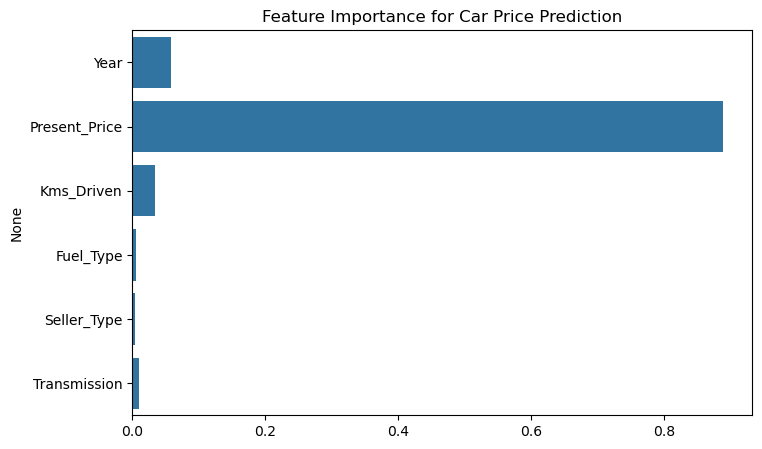

In [43]:
# Feature importance
importance = model.feature_importances_

features = X.columns

# Plot
plt.figure(figsize=(8,5))
sns.barplot(x=importance, y=features)
plt.title("Feature Importance for Car Price Prediction")
plt.show()

<u><b>STEP 7: User Input Prediction (Mini Interface)

In [45]:
def predict_price():
    print("Enter car details:")

    year = int(input("Year: "))
    present_price = float(input("Present Price: "))
    kms_driven = int(input("KMs Driven: "))
    fuel_type = int(input("Fuel Type (0=Petrol,1=Diesel,2=CNG): "))
    selling_type = int(input("Selling Type (0=Dealer,1=Individual): "))
    transmission = int(input("Transmission (0=Manual,1=Automatic): "))

    input_data = np.array([[year, present_price, kms_driven,
                             fuel_type, selling_type, transmission]])

    prediction = model.predict(input_data)

    print("\n Predicted Car Price:", prediction[0])

# Run prediction
predict_price()

Enter car details:


Year:  2022
Present Price:  10.5
KMs Driven:  7500
Fuel Type (0=Petrol,1=Diesel,2=CNG):  0
Selling Type (0=Dealer,1=Individual):  0
Transmission (0=Manual,1=Automatic):  1



 Predicted Car Price: 8.211700000000002


C:\Users\Administrator\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
